## Voting Ensembling

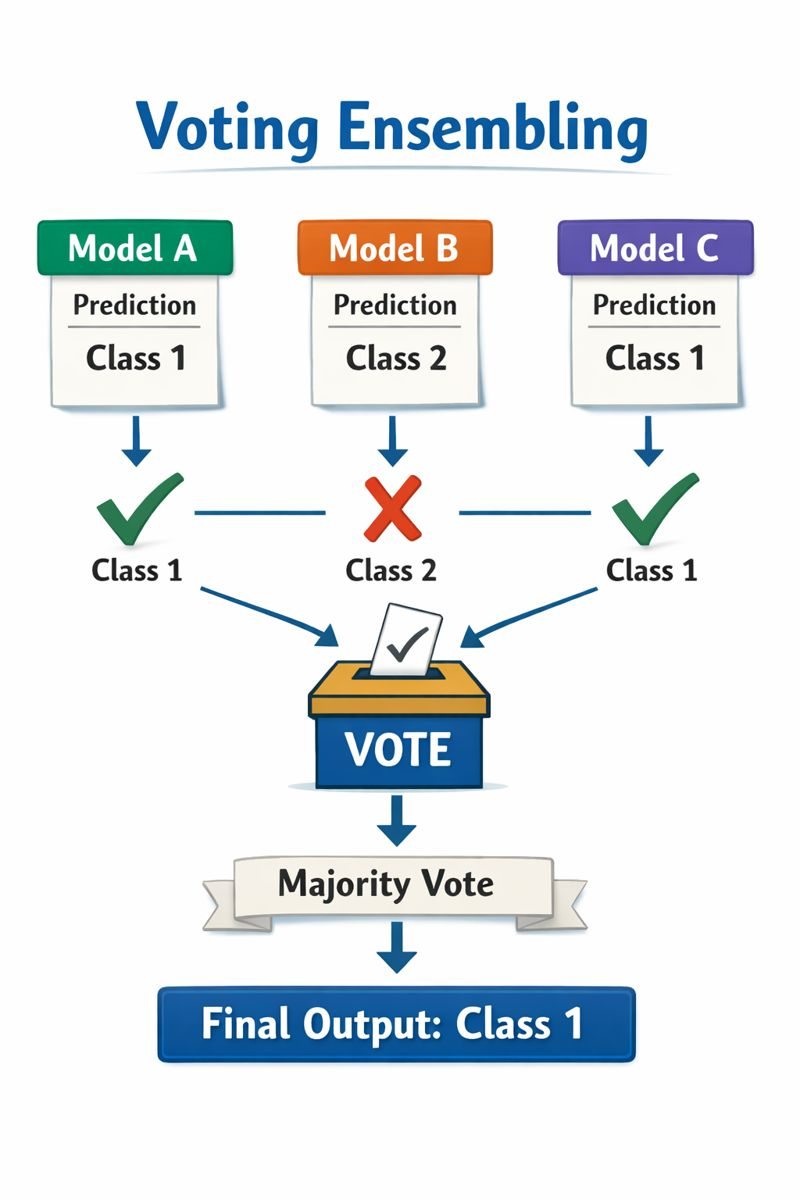

## How it works
## Train base models:
Multiple different models (e.g., Logistic Regression, SVM, Decision Tree) are trained on the same dataset.
## Combine predictions:
The final prediction is determined by aggregating the outputs of these individual models. 
## Types of voting
## Hard Voting (Majority Voting):
Each classifier casts a vote for a class label, and the class with the most votes wins.
## Example:
If models predict [Class A, Class B, Class A], the final vote is Class A.
## Soft Voting:
Each model provides class probabilities; these probabilities are averaged, and the class with the highest average probability is chosen.
Often performs better than hard voting as it considers model confidence.

## Weighted Voting: 
Similar to hard/soft voting but assigns weights to each model's vote based on its individual performance.
## Averaging (for Regression):
Calculates the simple average of the predictions from all models for the final output. 
## Benefits
## Improved Accuracy:
Combines diverse models for better overall prediction than any single model.
## Increased Robustness:
Reduces impact of mispredictions from a single weak model.
## Reduces Overfitting:
Mitigates individual model errors. 
## Key Requirement
The base models should be diverse and ideally not highly correlated to ensure they make different kinds of errors, making the ensemble effective. 

In [91]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [92]:
df = pd.read_csv("Salary Data.csv").dropna()
le_education = LabelEncoder()
le_job = LabelEncoder()
scaler = StandardScaler()
df["Education Level"] = le_education.fit_transform(df["Education Level"])
df["Job Title"] = le_job.fit_transform(df["Job Title"])
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Salary"] = scaler.fit_transform(df[["Salary"]])
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,-0.219559
1,28.0,0,1,17,3.0,-0.738498
2,45.0,1,2,130,15.0,1.025892
3,36.0,0,0,101,7.0,-0.842285
4,52.0,1,1,22,20.0,2.063768


In [93]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [94]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [95]:
LR=LinearRegression()
DTR = DecisionTreeRegressor(random_state=42)
RFR=RandomForestRegressor()

In [96]:
estimater = [("LR", LR), ("DTR", DTR),("RFR",RFR)]

for name, model in estimater:
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')
    print(name, ":", np.round(scores.mean(), 2))

LR : 0.89
DTR : 0.86
RFR : 0.92


In [97]:
estimater = [("LR", LR), ("DTR", DTR),("RFR",RFR)]
Voting = VotingRegressor(estimators=estimater)
Voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LR', ...), ('DTR', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


In [98]:
model_names = []
scores = []
for name, modell in estimater:
    modell.fit(X_train, y_train)        
    y_pred = modell.predict(X_test)     
    acc = r2_score(y_test, y_pred)      
    model_names.append(name)            
    scores.append(acc)                  
    print(f"{name} : {acc:.3f}")

LR : 0.896
DTR : 0.901
RFR : 0.932


In [99]:
y_pred_voting = Voting.predict(X_test)
voting_score = r2_score(y_test, y_pred_voting)
model_names.append("Voting Regressor")
scores.append(voting_score)
print(f"Voting Regressor : {voting_score:.3f}")

Voting Regressor : 0.938


In [100]:
model = VotingRegressor(estimators=estimater)
x=cross_val_score(model,X_train, y_train, cv=10, scoring='r2',)
print(np.round(np.mean(x),2))

0.91


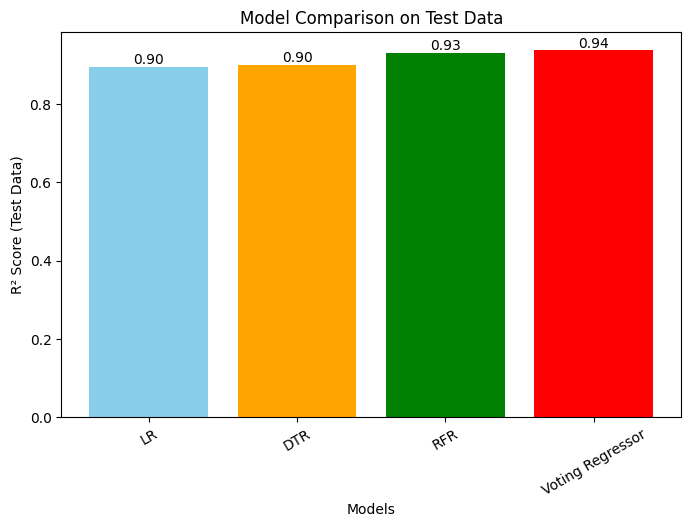

In [101]:
colors = ['skyblue', 'orange', 'green', 'red', 'purple']  
plt.figure(figsize=(8,5))
bars = plt.bar(model_names, scores, color=colors[:len(scores)])
plt.ylabel("R² Score (Test Data)")
plt.xlabel("Models")
plt.title("Model Comparison on Test Data")
plt.xticks(rotation=30)
for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.show()

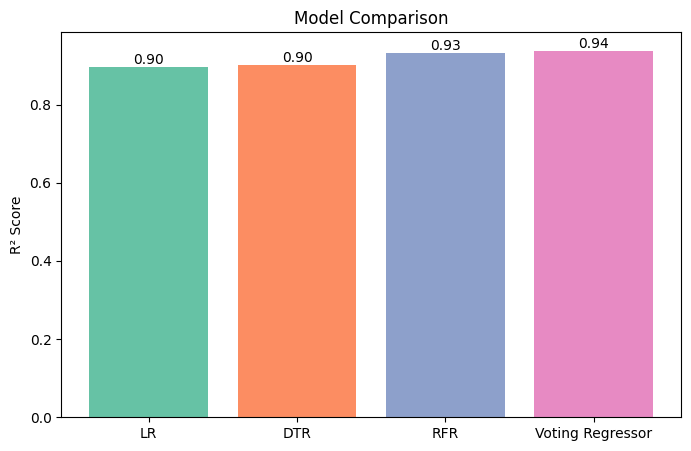

In [103]:
plt.figure(figsize=(8,5))
bars = plt.bar(model_names, scores, color=plt.cm.Set2(range(len(scores))))
for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.show()